In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

df = pd.read_csv("department_analysis.csv")
df.columns  # to decide features

Index(['department_id', 'department_name', 'location', 'annual_budget',
       'base_wait_days', 'manual_workload_multiplier', 'claim_denial_risk',
       'lab_delay_risk', 'total_manual_minutes', 'avg_manual_minutes',
       'task_count', 'error_rate', 'avg_overbooking', 'strain_rate',
       'provider_count', 'avg_wait_days', 'noshow_rate', 'appt_count'],
      dtype='str')

In [14]:
# define risk variables
risk_cols = ['total_manual_minutes', 'avg_overbooking',
             'avg_wait_days', 'noshow_rate', 'error_rate']

# define features
X = df[[
    "annual_budget",
    "base_wait_days",
    "manual_workload_multiplier",
    "claim_denial_risk",
    "lab_delay_risk",
    "provider_count",
    "avg_overbooking",
    "location"
]]

# split first
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# calculate risk score
z = df[risk_cols].apply(lambda c: (c - c.mean()) / c.std())
df['composite_risk_score'] = z.mean(axis=1)

# define outcome
y = df["composite_risk_score"]

# train & test
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

X_train = pd.get_dummies(X_train, columns=["location"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["location"], drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("R²:", round(r2_score(y_test, y_pred), 3))

MAE: 0.165
R²: 0.87


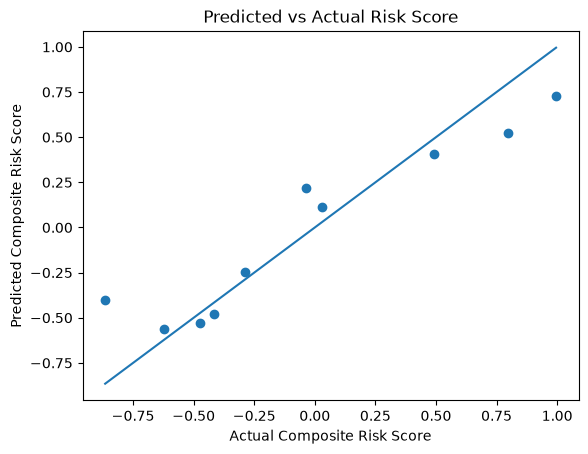

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Composite Risk Score")
plt.ylabel("Predicted Composite Risk Score")
plt.title("Predicted vs Actual Risk Score")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

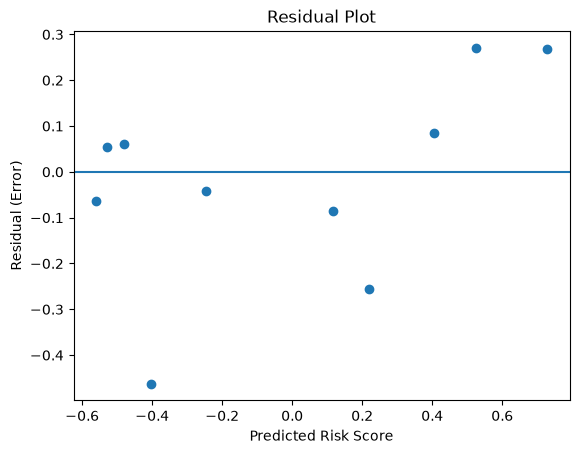

In [12]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Risk Score")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot")
plt.show()

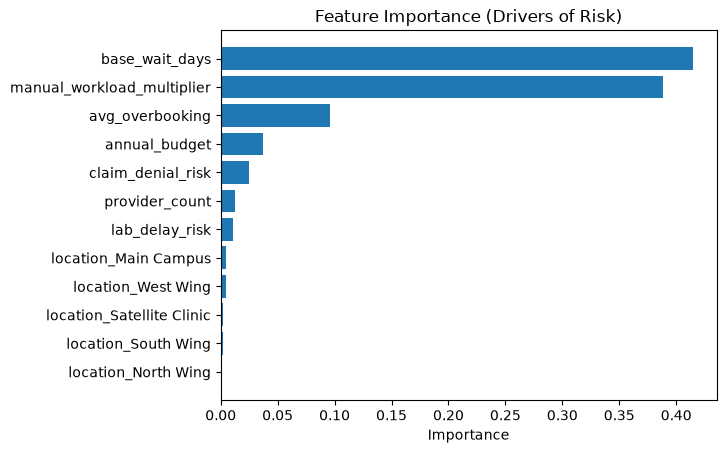

In [13]:
importances = model.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=True)

plt.figure()
plt.barh(feat_df["feature"], feat_df["importance"])
plt.title("Feature Importance (Drivers of Risk)")
plt.xlabel("Importance")
plt.show()